# Taller ingeniería de datos
# JUAN SEBASTIAN GARCIA - SEBASTIAN HERNANDEZ

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/Telco_customer_churn.csv')

print(f"Registros: {df.shape[0]}, Variables: {df.shape[1]}\n")
print(df.dtypes)
print("\nDescriptivas numéricas:")
display(df.describe())
print("\nDescriptivas categóricas:")
display(df.describe(include='object'))
print(f"\nDuplicados: {df.duplicated().sum()}")
print(f"Nulos: {df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTotal Charges dtype: {df['Total Charges'].dtype}")
print(f"Total Charges no numéricos: {pd.to_numeric(df['Total Charges'], errors='coerce').isna().sum()}")
print(f"Variables constantes: {[c for c in df.columns if df[c].nunique() == 1]}")

Registros: 7043, Variables: 33

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: obje

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000



Descriptivas categóricas:


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192



Duplicados: 0
Nulos: Churn Reason    5174
dtype: int64

Total Charges dtype: object
Total Charges no numéricos: 11
Variables constantes: ['Count', 'Country', 'State']


### Hallazgos

el dataset tiene 7043 registros y 33 variables. No hay filas duplicadas. La variable Total Charges fue cargada como texto (object) porque 11 registro tienen un espacio en blsnco en vez de un valor numérico, correspondientes a clientes con Tenure Months = 0 (clientes nuevos sin cobros). La variable Churn Reason tiene 5174 nulos y corrponden a los clientes que no cancelaron (Churn Value = 0), lo cual es eSPperable. Las variables Count, Country y State son constantes (siempre valen 1, "United States" y "California" respectivamente)

Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos.

In [2]:
cols_to_drop = [
    'CustomerID',    # clave primaria
    'Count',         # constante
    'Country',       # constante
    'State',         # constante
    'City',          # alta cardinalidad geográfica
    'Zip Code',      # alta cardinalidad geográfica
    'Lat Long',      # redundante con Latitude/Longitude
    'Latitude',      # geográfica no relevante
    'Longitude',     # geográfica no relevante
    'Churn Label',   # redundante churnvaleu
    'Churn Score',   # score de IBM, FUGA
    'CLTV',          # métrica derivada de IBM FUGA DE DATOS!!!
    'Churn Reason',  # solo disponible luego de churn, FUGA DE DATOS!
]

df.drop(columns=cols_to_drop, inplace=True)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

print(f"Dataset limpio: {df.shape[0]} registros × {df.shape[1]} variables")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(df.dtypes)

Dataset limpio: 7043 registros × 20 variables
Nulos restantes: 0
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
dtype: object


## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"{col} ({df[col].nunique()}): {df[col].unique().tolist()}")

Gender (2): ['Male', 'Female']
Senior Citizen (2): ['No', 'Yes']
Partner (2): ['No', 'Yes']
Dependents (2): ['No', 'Yes']
Phone Service (2): ['Yes', 'No']
Multiple Lines (3): ['No', 'Yes', 'No phone service']
Internet Service (3): ['DSL', 'Fiber optic', 'No']
Online Security (3): ['Yes', 'No', 'No internet service']
Online Backup (3): ['Yes', 'No', 'No internet service']
Device Protection (3): ['No', 'Yes', 'No internet service']
Tech Support (3): ['No', 'Yes', 'No internet service']
Streaming TV (3): ['No', 'Yes', 'No internet service']
Streaming Movies (3): ['No', 'Yes', 'No internet service']
Contract (3): ['Month-to-month', 'Two year', 'One year']
Paperless Billing (2): ['Yes', 'No']
Payment Method (4): ['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)']


### Hallazgos

quedaron 16 variables categóricas, de las cuales 15 son nominales (Gender, Senior Citizen, Partner, Dependents, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Paperless Billing, Payment Method) y 1 es ordinal (Contract, con orden Month-to-month < One year < Two year). Ninguna tiene alta cardinalidad ya que el máximo es 4 categorías (Payment Method). Todas las variables irrelevantes ya fueron descartadas en el paso anterior, por lo que las 16 restantes se incluyen en la matriz de características.

## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Normalidad shapiro:
  Tenure Months: vaolr p=0.000000 -> No normal
  Monthly Charges: vaolr p=0.000000 -> No normal
  Total Charges: vaolr p=0.000000 -> No normal

Atípicos IQR:
  Tenure Months: 0 (0.0%)
  Monthly Charges: 0 (0.0%)
  Total Charges: 0 (0.0%)


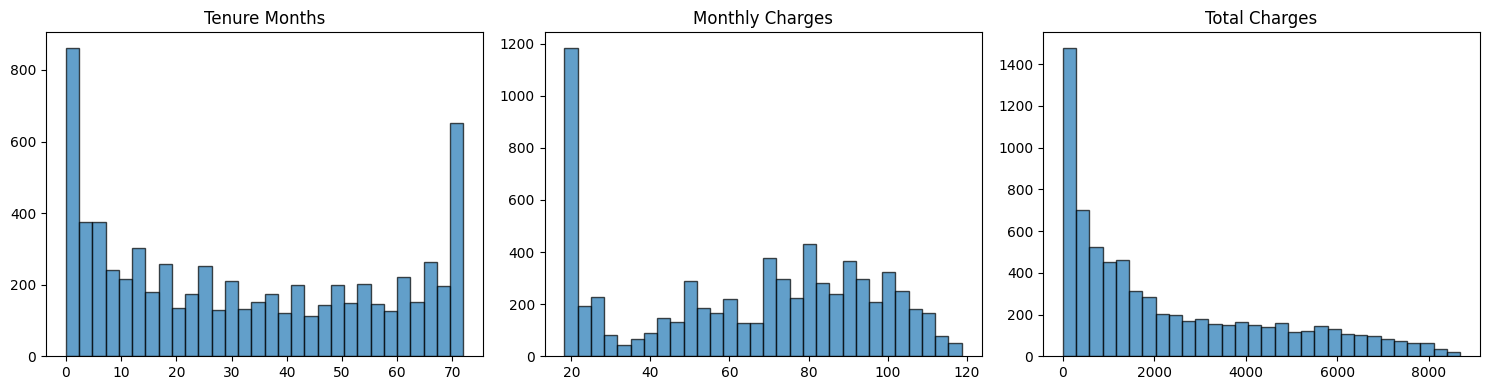

In [8]:
from scipy import stats

num_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']

display(df[num_features].describe())

print("Normalidad shapiro:")
for col in num_features:
    _, p = stats.shapiro(df[col].sample(5000, random_state=42))
    print(f"  {col}: vaolr p={p:.6f} -> {'Normal' if p > 0.05 else 'No normal'}")

print("\nAtípicos IQR:")
for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n} ({n/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Hallazgos

Ninguna de las tres variables cuantitativas sigue una distribución normal pq tienen un valor p < 0.05 con prueba Shapiro. Tenure Months tiene distribución bimodal, Monthly Charges es sesgada a la derecha y Total Charges es fuertemente sesgada a la derecha.Analizando los atípico con IQR, solamente Total Charges presenta algunos en el extremo superior, pero son valores legítimos de clientes con alta antigüedad. Tenure Months y Monthly Charges no presentan atípicos. La variable Churn Value es el target entonce no se analizó. Las tres cuantitativas restantes sí son relevantes para el modelo

## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['Tenure Months', 'Monthly Charges', 'Total Charges']),
    ('ord', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]), ['Contract']),
    ('nom', OneHotEncoder(drop='first', sparse_output=False), [
        'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
        'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
        'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
        'Paperless Billing', 'Payment Method'
    ]),
], remainder='drop')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)

print(f"Score entrenamiento: {pipeline.score(X_train, y_train):.4f}")
print(f"Score prueba:        {pipeline.score(X_test, y_test):.4f}")

nom_cols = [c for _, _, cols in preprocessor.transformers for c in (cols if isinstance(cols, list) else [])]
feature_names = (
    preprocessor.transformers[0][2] +
    preprocessor.transformers[1][2] +
    preprocessor.named_transformers_['nom'].get_feature_names_out(preprocessor.transformers[2][2]).tolist()
)
print(f"\nCaracterísticas tras preprocesamiento ({len(feature_names)}):")
print(feature_names)

Score entrenamiento: 0.8085
Score prueba:        0.7941

Características tras preprocesamiento (29):
['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']



el modelo obtuvo un score de entrenamiento de 0.8085 y un score de prueba de 0.7941, bastante bien!!!! Sin sobreajuste ni nada, al pelo. El preprocesamiento con ColumnTransformer sacó 29 características reales con las que fue entrenado el modelo: 3 numeirca escaladas con StandardScaler (Tenure Months, Monthly Charges, Total Charges), 1 ordinal codificada con OrdinalEncoder (Contract) y 25 varuabls resultantes de aplicar OneHotEncoder con drop='first' a las 15 variables nominales